In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set(style="whitegrid")

In [2]:
DATA_PATH = "../data/raw/data.csv"

df = pd.read_csv(DATA_PATH)

df.head()

,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
0,TransactionId_76871,BatchId_36123,AccountId_3957,SubscriptionId_887,CustomerId_4406,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,1000.0,1000,2018-11-15T02:18:49Z,2,0
1,TransactionId_73770,BatchId_15642,AccountId_4841,SubscriptionId_3829,CustomerId_4406,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-20.0,20,2018-11-15T02:19:08Z,2,0
2,TransactionId_26203,BatchId_53941,AccountId_4229,SubscriptionId_222,CustomerId_4683,UGX,256,ProviderId_6,ProductId_1,airtime,ChannelId_3,500.0,500,2018-11-15T02:44:21Z,2,0
3,TransactionId_380,BatchId_102363,AccountId_648,SubscriptionId_2185,CustomerId_988,UGX,256,ProviderId_1,ProductId_21,utility_bill,ChannelId_3,20000.0,21800,2018-11-15T03:32:55Z,2,0
4,TransactionId_28195,BatchId_38780,AccountId_4841,SubscriptionId_3829,CustomerId_988,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-644.0,644,2018-11-15T03:34:21Z,2,0


In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.info()

Rows: 95662
Columns: 16
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95662 entries, 0 to 95661
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   TransactionId         95662 non-null  object 
 1   BatchId               95662 non-null  object 
 2   AccountId             95662 non-null  object 
 3   SubscriptionId        95662 non-null  object 
 4   CustomerId            95662 non-null  object 
 5   CurrencyCode          95662 non-null  object 
 6   CountryCode           95662 non-null  int64  
 7   ProviderId            95662 non-null  object 
 8   ProductId             95662 non-null  object 
 9   ProductCategory       95662 non-null  object 
 10  ChannelId             95662 non-null  object 
 11  Amount                95662 non-null  float64
 12  Value                 95662 non-null  int64  
 13  TransactionStartTime  95662 non-null  object 
 14  PricingStrategy       95662 non-null  int64  


In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
TransactionId,95662,95662,TransactionId_35670,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BatchId,95662,94809,BatchId_67019,28,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AccountId,95662,3633,AccountId_4841,30893,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SubscriptionId,95662,3627,SubscriptionId_3829,32630,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CustomerId,95662,3742,CustomerId_7343,4091,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CurrencyCode,95662,1,UGX,95662,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CountryCode,95662.0,NaN,NaN,NaN,256.0,0.0,256.0,256.0,256.0,256.0,256.0
ProviderId,95662,6,ProviderId_4,38189,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ProductId,95662,23,ProductId_6,32635,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ProductCategory,95662,9,financial_services,45405,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Missing Values

In [5]:
missing_values = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percentage": df.isnull().mean() * 100
}).sort_values(by="missing_count", ascending=False)

missing_values

,missing_count,missing_percentage
TransactionId,0,0.0
BatchId,0,0.0
AccountId,0,0.0
SubscriptionId,0,0.0
CustomerId,0,0.0
CurrencyCode,0,0.0
CountryCode,0,0.0
ProviderId,0,0.0
ProductId,0,0.0
ProductCategory,0,0.0


Duplicate Rows

In [6]:
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 0


Convert Transaction Time

In [7]:
df["TransactionStartTime"] = pd.to_datetime(df["TransactionStartTime"])

df["TransactionHour"] = df["TransactionStartTime"].dt.hour
df["TransactionDay"] = df["TransactionStartTime"].dt.day
df["TransactionMonth"] = df["TransactionStartTime"].dt.month
df["TransactionYear"] = df["TransactionStartTime"].dt.year

df[["TransactionStartTime", "TransactionHour", "TransactionDay", "TransactionMonth", "TransactionYear"]].head()

,TransactionStartTime,TransactionHour,TransactionDay,TransactionMonth,TransactionYear
0,2018-11-15 02:18:49+00:00,2,15,11,2018
1,2018-11-15 02:19:08+00:00,2,15,11,2018
2,2018-11-15 02:44:21+00:00,2,15,11,2018
3,2018-11-15 03:32:55+00:00,3,15,11,2018
4,2018-11-15 03:34:21+00:00,3,15,11,2018


Numerical Feature Distributions

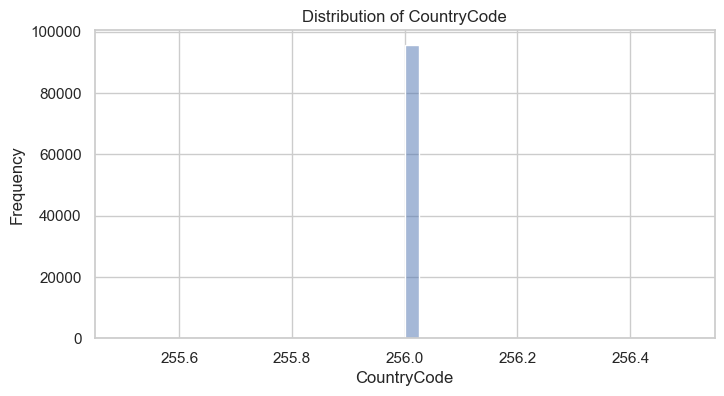

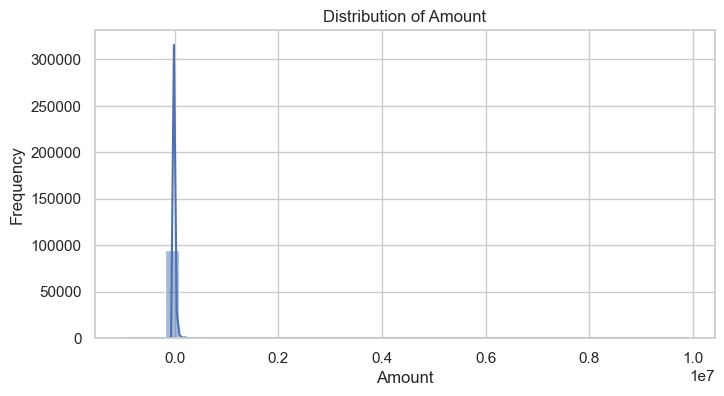

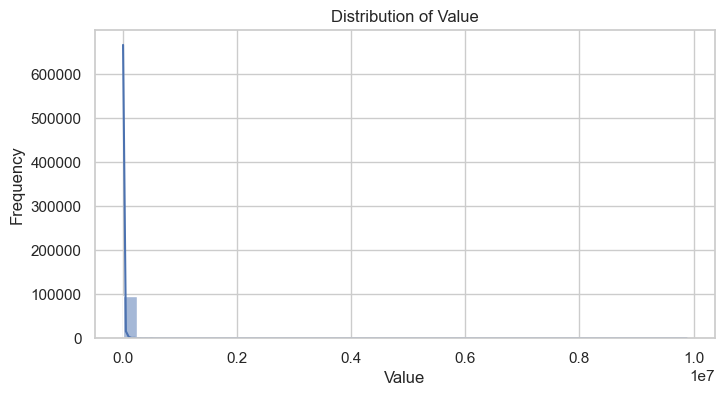

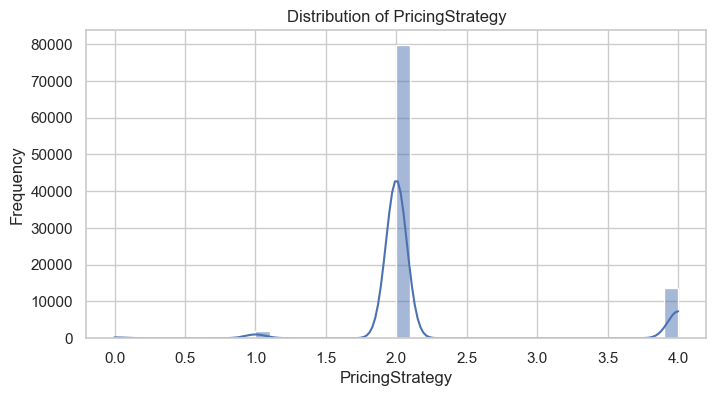

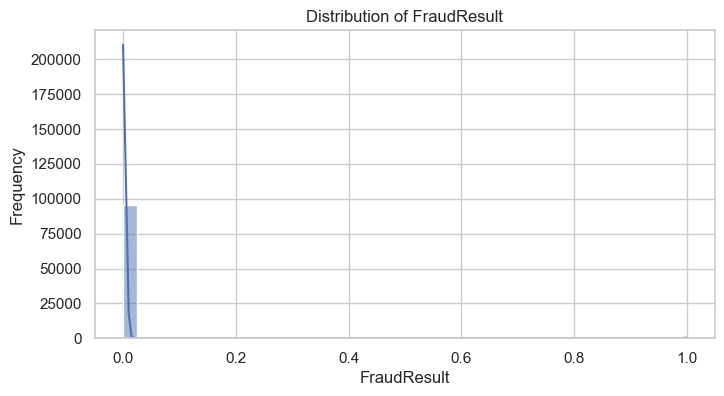

In [8]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], kde=True, bins=40)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

Categorical Feature Distributions

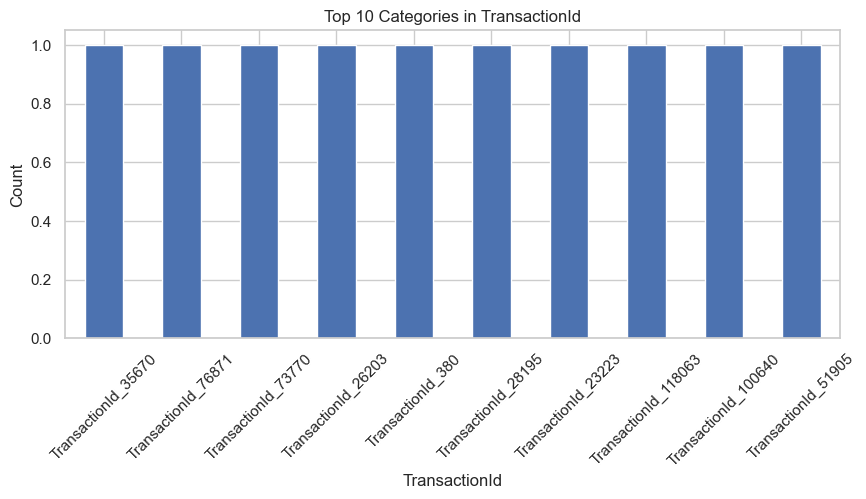

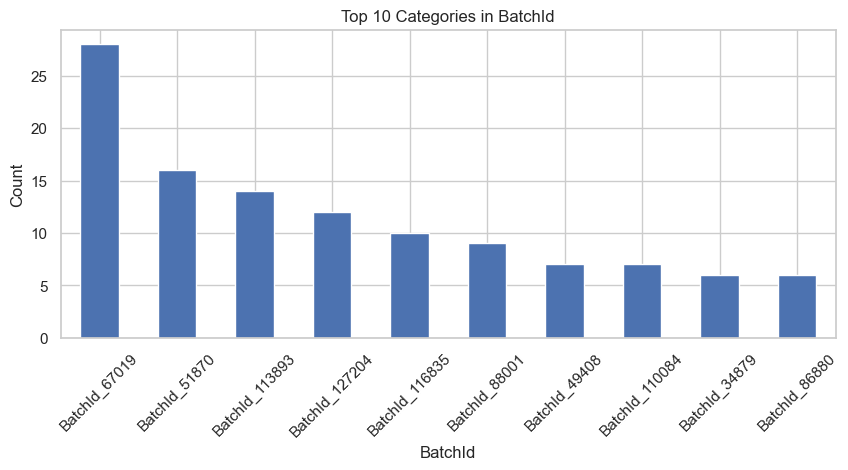

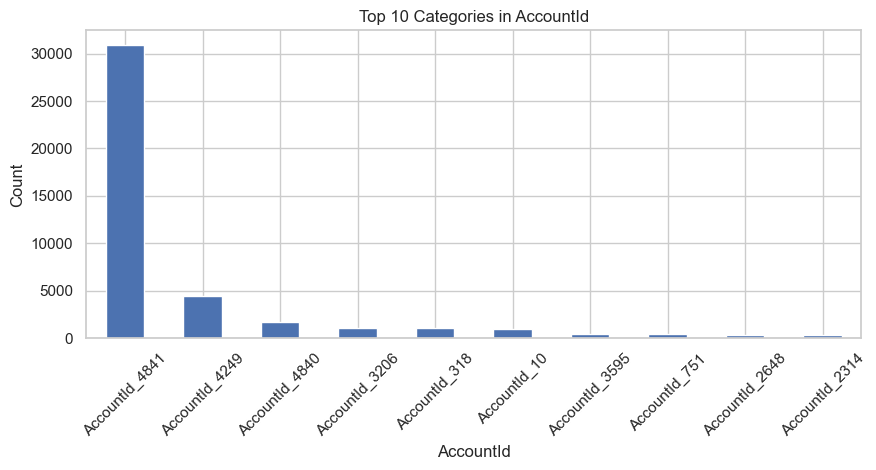

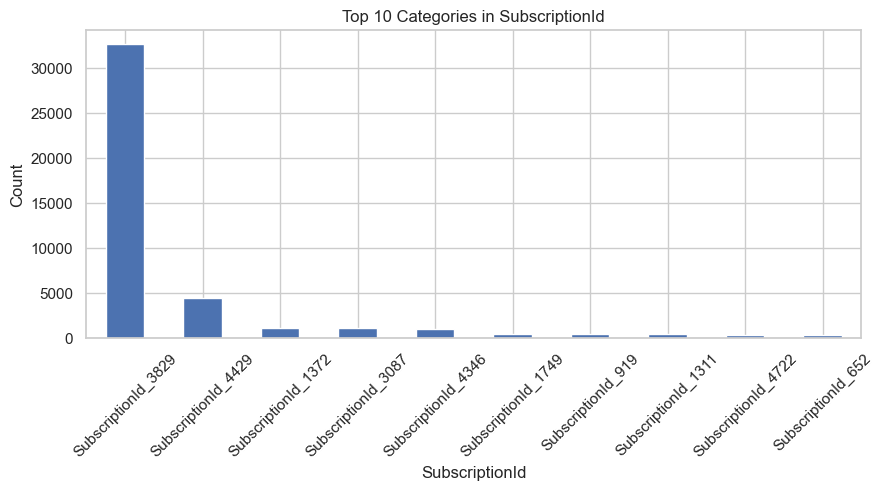

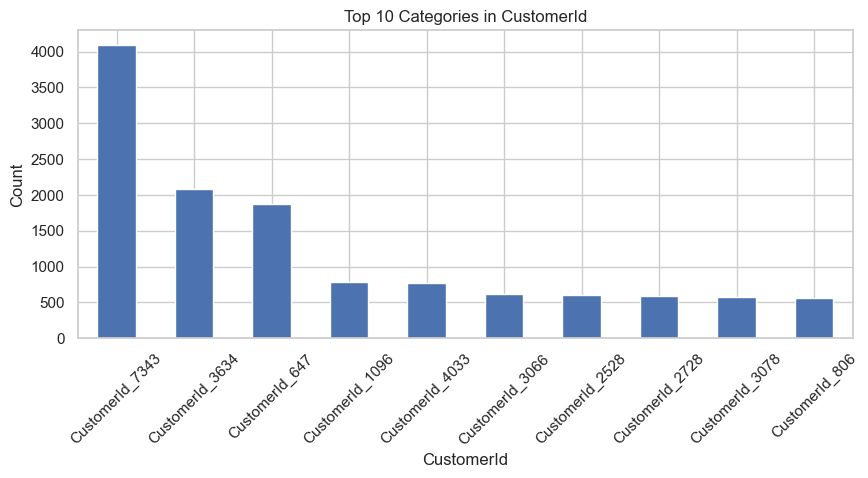

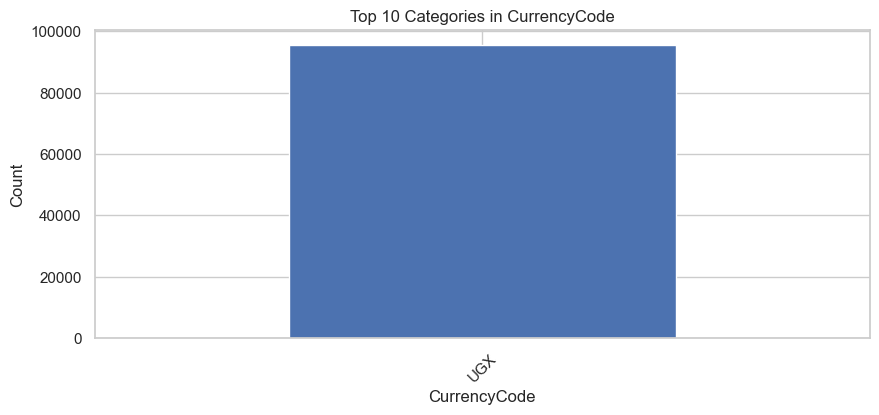

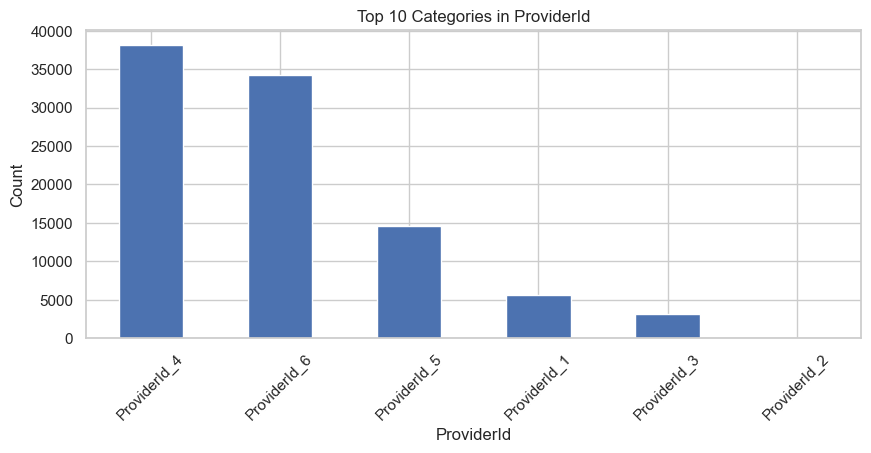

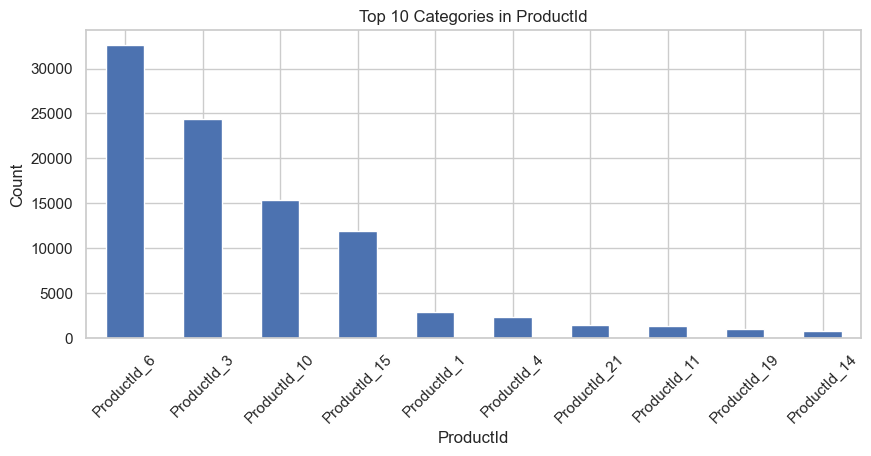

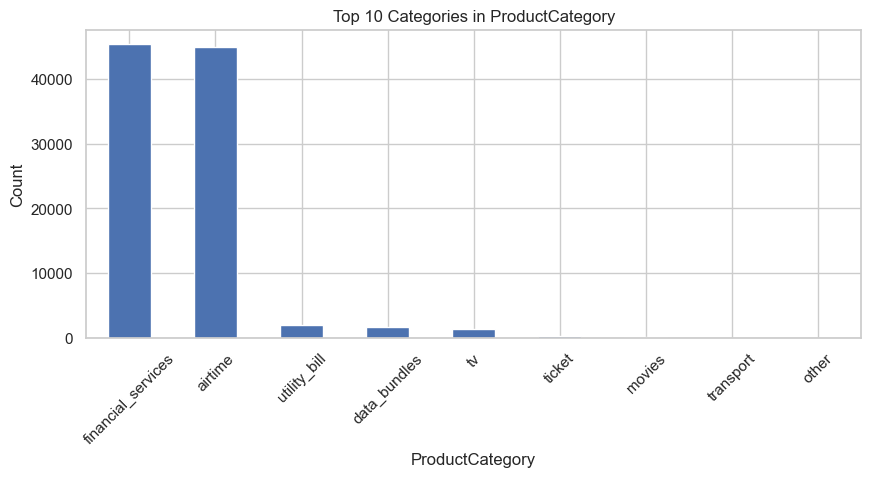

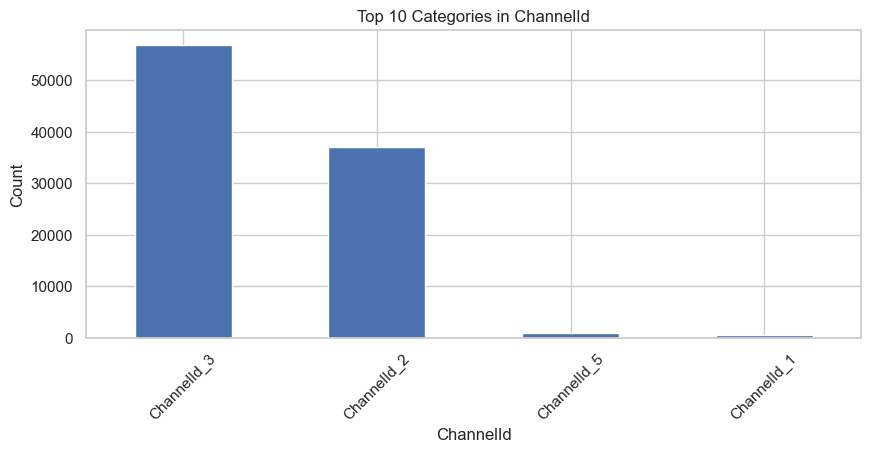

In [9]:
categorical_cols = df.select_dtypes(include=["object"]).columns

for col in categorical_cols:
    plt.figure(figsize=(10, 4))
    df[col].value_counts().head(10).plot(kind="bar")
    plt.title(f"Top 10 Categories in {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.show()

Corelation Analysis

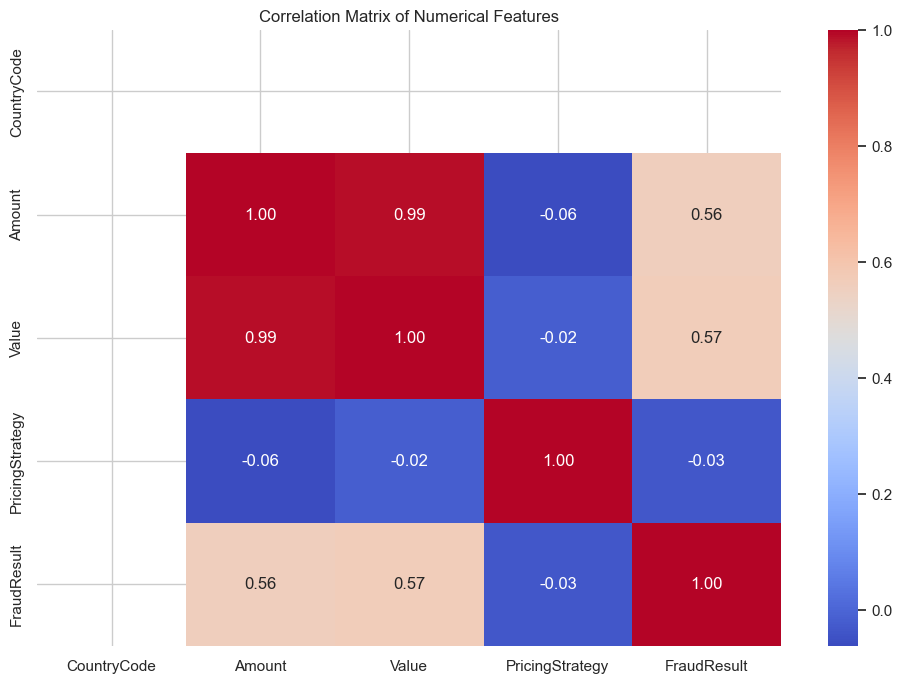

In [10]:
plt.figure(figsize=(12, 8))

correlation_matrix = df[numeric_cols].corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Numerical Features")
plt.show()

Outlier Detection

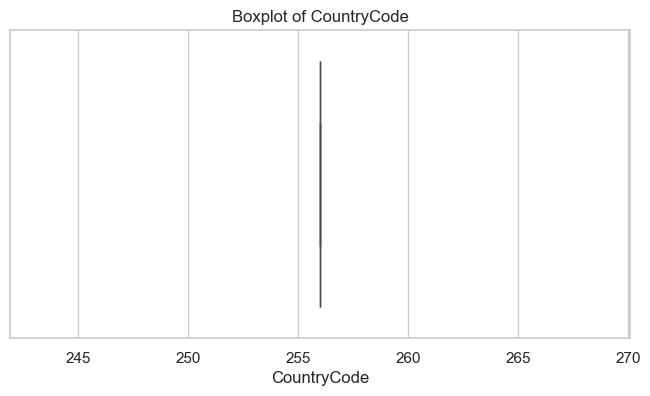

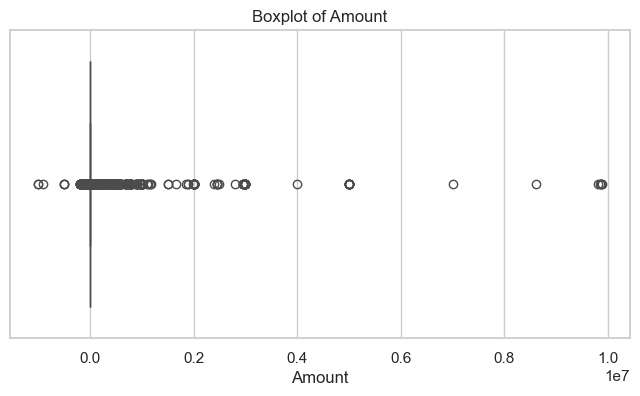

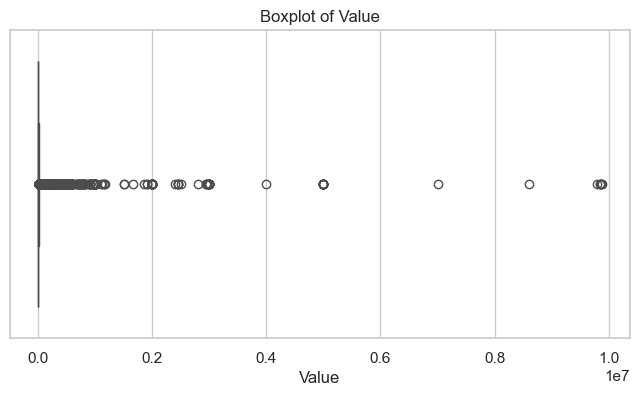

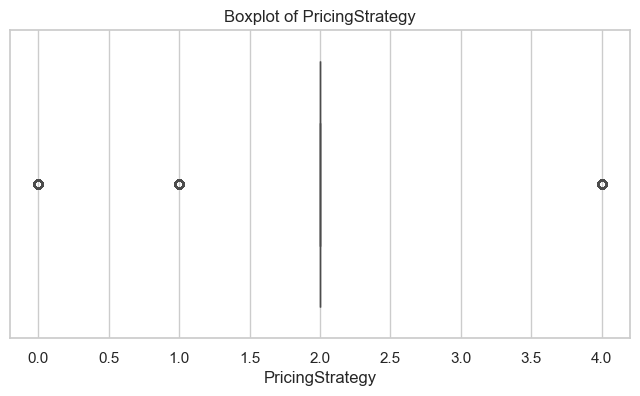

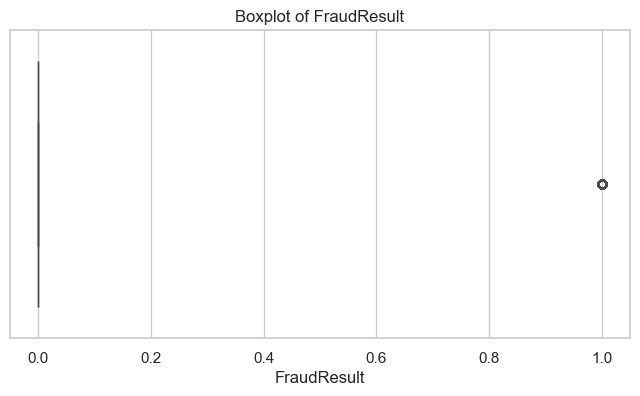

In [11]:
for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.show()

Fraud Result Distribution

In [12]:
df["FraudResult"].value_counts(normalize=True) * 100

FraudResult
0    99.798248
1     0.201752
Name: proportion, dtype: float64

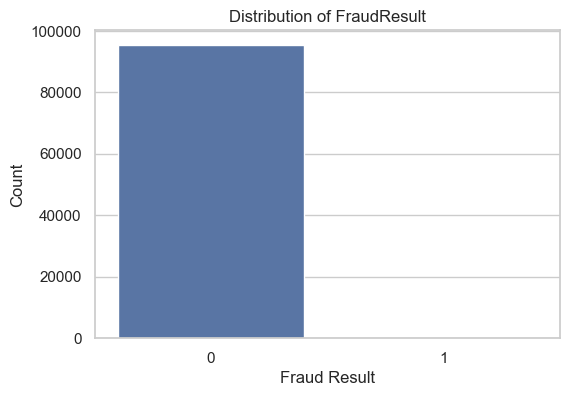

In [13]:
plt.figure(figsize=(6, 4))
sns.countplot(x="FraudResult", data=df)
plt.title("Distribution of FraudResult")
plt.xlabel("Fraud Result")
plt.ylabel("Count")
plt.show()

Customer level Transaction Behaviour

In [14]:
customer_summary = df.groupby("CustomerId").agg(
    total_transaction_amount=("Amount", "sum"),
    average_transaction_amount=("Amount", "mean"),
    transaction_count=("TransactionId", "count"),
    std_transaction_amount=("Amount", "std"),
    total_transaction_value=("Value", "sum")
).reset_index()

customer_summary.head()

,CustomerId,total_transaction_amount,average_transaction_amount,transaction_count,std_transaction_amount,total_transaction_value
0,CustomerId_1,-10000.0,-10000.000000,1,NaN,10000
1,CustomerId_10,-10000.0,-10000.000000,1,NaN,10000
2,CustomerId_1001,20000.0,4000.000000,5,6558.963333,30400
3,CustomerId_1002,4225.0,384.090909,11,560.498966,4775
4,CustomerId_1003,20000.0,3333.333333,6,6030.478146,32000


Top 10 Customers by Transaction count

In [15]:
top_customers = customer_summary.sort_values(
    by="transaction_count",
    ascending=False
).head(10)

top_customers

,CustomerId,total_transaction_amount,average_transaction_amount,transaction_count,std_transaction_amount,total_transaction_value
3478,CustomerId_7343,-104900000.0,-25641.652408,4091,12952.599898,104900000
1969,CustomerId_3634,2628793.0,1260.811990,2085,5388.206928,2726207
3390,CustomerId_647,3633564.0,1944.121990,1869,7715.389537,3905264
66,CustomerId_1096,1949226.0,2486.257653,784,17819.372757,2041334
2271,CustomerId_4033,1768355.5,2272.950514,778,10382.687289,1927834
1494,CustomerId_3066,1119116.0,1828.620915,612,5212.148703,1171282
1072,CustomerId_2528,1695194.3,2779.007049,610,22872.844887,1868148
1224,CustomerId_2728,1250976.6,2134.772355,586,5268.094459,1340378
1504,CustomerId_3078,2438140.0,4255.043630,573,22554.029939,2541260
3605,CustomerId_806,2002972.8,3596.001436,557,38535.621914,2097380


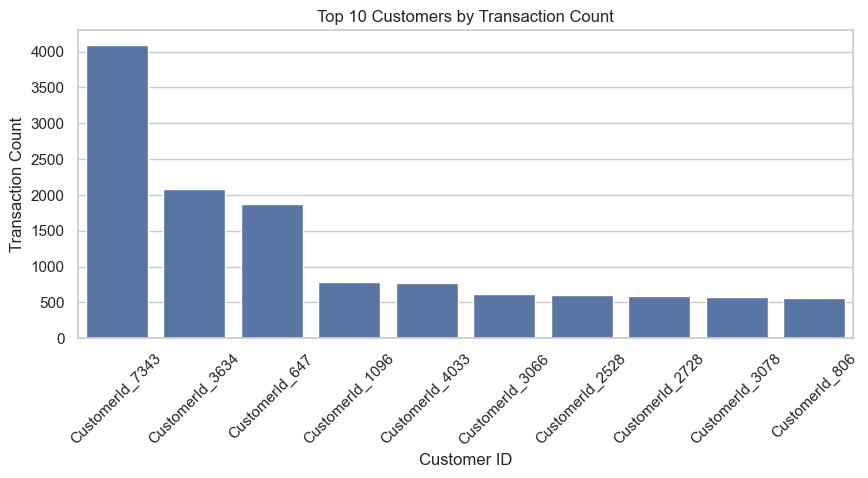

In [16]:
plt.figure(figsize=(10, 4))
sns.barplot(
    data=top_customers,
    x="CustomerId",
    y="transaction_count"
)
plt.title("Top 10 Customers by Transaction Count")
plt.xlabel("Customer ID")
plt.ylabel("Transaction Count")
plt.xticks(rotation=45)
plt.show()

Product Category Analysis

In [17]:
product_category_summary = df.groupby("ProductCategory").agg(
    transaction_count=("TransactionId", "count"),
    total_amount=("Amount", "sum"),
    average_amount=("Amount", "mean")
).sort_values(by="transaction_count", ascending=False)

product_category_summary

,transaction_count,total_amount,average_amount
ProductCategory,,,
financial_services,45405,519231577.5,11435.559465
airtime,45027,37055259.0,822.956426
utility_bill,1920,33087089.0,17232.858854
data_bundles,1613,5487700.0,3402.169870
tv,1279,21284000.0,16641.125880
ticket,216,20886500.0,96696.759259
movies,175,1353500.0,7734.285714
transport,25,4256000.0,170240.000000
other,2,1000.0,500.000000


# EDA Summary: Key Insights

1. The dataset contains transaction-level records, meaning each row represents a single transaction rather than a single customer. Therefore, customer-level aggregation is required before building a credit risk model.

2. The `Amount` and `Value` columns show strong transaction-size variability, indicating the presence of high-value transactions and potential outliers. These features may require scaling or transformation before modeling.

3. The dataset includes several categorical variables such as `ProductCategory`, `ProviderId`, `ProductId`, and `ChannelId`. These variables need encoding before they can be used in machine learning models.

4. Missing value analysis is necessary before modeling. Any missing values should be handled using an automated preprocessing pipeline to avoid manual and non-reproducible cleaning.

5. Since the dataset does not contain a true loan default label, the credit risk target must be engineered using customer behavior. RFM analysis will be used in the next stage to create a proxy `is_high_risk` target variable.